<a href="https://colab.research.google.com/github/VladyslavBiblyi/CSC-349-OL1/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing libraries



In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_selector, make_column_transformer

# Downloading and loading the data

In [2]:
def load_cybersecurity_data():
    file_path = Path("datasets/cybersecurity_intrusion_data.csv")

    if not file_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = ("https://raw.githubusercontent.com/VladyslavBiblyi/CSC-349-OL1/main/HW2/cybersecurity_intrusion_data.csv")
        urllib.request.urlretrieve(url, file_path)

    return pd.read_csv(file_path)

cyber = load_cybersecurity_data()

# Inspecting the data

In [3]:
cyber.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [4]:
cyber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [5]:
cyber.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [6]:
cl = [
    "network_packet_size",
    "session_duration",
    "login_attempts",
    "protocol_type",
    "browser_type"
]

cyber[cl].describe(include="all")

,network_packet_size,session_duration,login_attempts,protocol_type,browser_type
count,9537.000000,9537.000000,9537.000000,9537,9537
unique,NaN,NaN,NaN,3,5
top,NaN,NaN,NaN,TCP,Chrome
freq,NaN,NaN,NaN,6624,5137
mean,500.430639,792.745312,4.032086,NaN,NaN
std,198.379364,786.560144,1.963012,NaN,NaN
min,64.000000,0.500000,1.000000,NaN,NaN
25%,365.000000,231.953006,3.000000,NaN,NaN
50%,499.000000,556.277457,4.000000,NaN,NaN
75%,635.000000,1105.380602,5.000000,NaN,NaN


# Removing the non-inform identifier

In [7]:
if "session_id" in cyber.columns:
    cyber = cyber.drop("session_id", axis=1)

cyber.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


# Counting missing values

In [8]:
cyber.isnull().sum()

,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


In [9]:
missing_values = pd.DataFrame({
    "count": cyber.isnull().sum(),
    "percent": (cyber.isnull().mean() * 100).round(2)
})

missing_values

,count,percent
network_packet_size,0,0.00
protocol_type,0,0.00
login_attempts,0,0.00
session_duration,0,0.00
encryption_used,1966,20.61
ip_reputation_score,0,0.00
failed_logins,0,0.00
browser_type,0,0.00
unusual_time_access,0,0.00
attack_detected,0,0.00


# Separating the target from the features

In [10]:
X = cyber.drop(columns=["attack_detected"])
y = cyber["attack_detected"]

# Separating numerical and categorical col

In [11]:
num_col = X.select_dtypes(include="number").columns

cat_col = X.select_dtypes(
    include=["object", "category"]
).columns

print("Numerical:", list(num_col))
print("Categorical:", list(cat_col))

Numerical: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']
Categorical: ['protocol_type', 'encryption_used', 'browser_type']


# Pipeline

In [12]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

In [13]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# Transformer


In [14]:
preprocessing = make_column_transformer(
    (
        num_pipeline,
        make_column_selector(dtype_include=np.number)
    ),
    (
        cat_pipeline,
        make_column_selector(dtype_include=object)
    )
)

In [16]:
cyber_prepared = preprocessing.fit_transform(X)

cyber_prepared

array([[ 0.49689911, -0.01634592, -0.38112504, ...,  0.        ,
         0.        ,  0.        ],
       [-0.14332201, -0.52579383,  0.97295964, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.64813245, -0.52579383, -0.91250324, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.82457134,  0.49310198, -0.96320007, ...,  1.        ,
         0.        ,  0.        ],
       [-0.47603535, -0.01634592, -0.89772872, ...,  0.        ,
         0.        ,  0.        ],
       [-0.80874869,  1.00254989, -0.89745912, ...,  0.        ,
         0.        ,  0.        ]])

# Corralation


In [17]:
correlation = cyber.select_dtypes(include=np.number).corr()

correlation

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
network_packet_size,1.000000,-0.001890,0.021650,0.002320,-0.011676,-0.001255,-0.006798
login_attempts,-0.001890,1.000000,0.006392,-0.002618,-0.013507,0.007349,0.277320
session_duration,0.021650,0.006392,1.000000,-0.005077,0.019375,0.012930,0.041602
ip_reputation_score,0.002320,-0.002618,-0.005077,1.000000,0.015613,-0.003146,0.211540
failed_logins,-0.011676,-0.013507,0.019375,0.015613,1.000000,0.006131,0.363726
unusual_time_access,-0.001255,0.007349,0.012930,-0.003146,0.006131,1.000000,0.008652
attack_detected,-0.006798,0.277320,0.041602,0.211540,0.363726,0.008652,1.000000


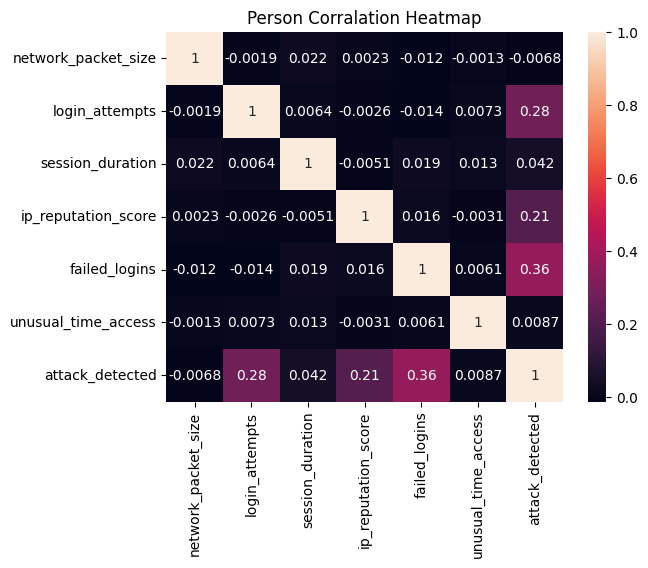

In [23]:
sns.heatmap(
    correlation,
    annot=True,
)

plt.title("Person Corralation Heatmap")
plt.show()

# two distribution plots and one scatter plot

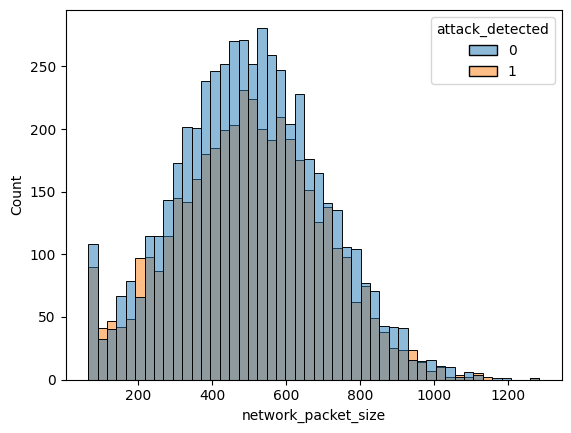

In [24]:
sns.histplot(data=cyber,
             x="network_packet_size",
             hue="attack_detected")
plt.show()


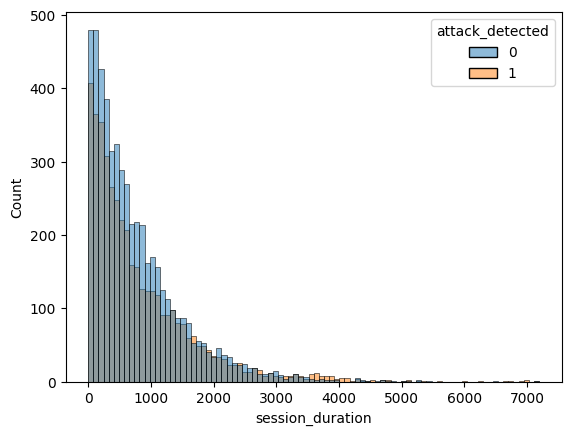

In [25]:
sns.histplot(data=cyber,
             x="session_duration",
             hue="attack_detected")
plt.show()

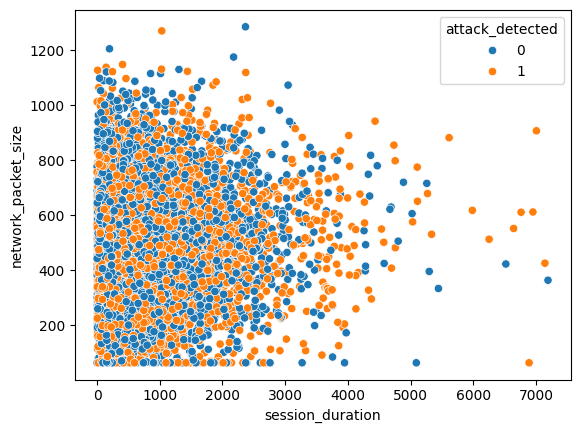

In [30]:
sns.scatterplot(data=cyber,
    x="session_duration",
    y="network_packet_size",
    hue="attack_detected"
)
plt.show()